In [131]:
import pandas as pd
import numpy as np
import sys
import os

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.analysis.sensitivity import SensitivityAnalyzer
from omegaconf import OmegaConf
from scipy.stats.qmc import LatinHypercube

In [132]:
from sklearn.model_selection import train_test_split
data = pd.read_pickle('../sampling_test/validated_final_df_57344_imputed.pkl')
data = data[data['Ucell'].apply(lambda x: all(val > 0 for val in x))]

exploaded_df = data.explode(['ifc', 'Ucell'])

np.random.seed(42)

parameters = ['Tfc', 'i0_c_ref', 'Pa_des', 'kappa_c', 'kappa_co', 'tau', 'Re', 'ifc']

# Get unique curve IDs and split train/test
unique_ids = data['SHA256'].unique()
train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

test_df = exploaded_df[exploaded_df['SHA256'].isin(test_ids)]

In [133]:
import os
import pandas as pd

def load_all_pysr_equations(base_dir="../models/pysr_equations/", output_csv="all_equations_combined.csv"):
    """
    Loop through subfolders in a given directory, read each equations.csv file,
    and combine all equations into a single DataFrame.

    Args:
        base_dir (str): Path to the directory containing PySR model subfolders.
        output_csv (str): Output CSV path to save the combined equations.
    
    Returns:
        pd.DataFrame: Combined DataFrame of all equations.
    """
    all_equations = []

    for subdir in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, subdir)
        equations_file = os.path.join(folder_path, "hall_of_fame.csv")

        if os.path.isdir(folder_path) and os.path.isfile(equations_file):
            df = pd.read_csv(equations_file)
            df["model_folder"] = subdir  # track which folder it came from
            all_equations.append(df)

    if not all_equations:
        print("No equations.csv files found.")
        return pd.DataFrame()

    combined_df = pd.concat(all_equations, ignore_index=True)
    if output_csv is not None:
        combined_df.to_csv(output_csv, index=False)
        print(f"Saved combined equations to {output_csv}")
    return combined_df

df_all_equations = load_all_pysr_equations(output_csv=None)
df_all_equations = df_all_equations[df_all_equations['model_folder'] == '20250728_153342']  # Example check, adjust as needed

In [175]:
import re
import numpy as np
import pandas as pd
from sympy import sympify, symbols, lambdify
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np
import pandas as pd
import re
from sympy import sympify, symbols, lambdify
from sklearn.metrics import r2_score, mean_squared_error

# Define NumPy-safe unary operators
numpy_locals = {
    'square': lambda x: np.power(x, 2),
    'cube': lambda x: np.power(x, 3),
    'inv': lambda x: 1 / x,
    'neg': lambda x: -x,
}

def evaluate_equations_with_parameters(df_equations, X, y, parameters):
    results = []
    X_df = pd.DataFrame(X, columns=parameters)

    for _, row in df_equations.iterrows():
        equation_str = str(row['Equation'])

        try:
            # Replace x0, x1, ... with parameter names
            for i, name in enumerate(parameters):
                equation_str = equation_str.replace(f'x{i}', name)

            # Parse without custom locals — just pure sympy parsing
            expr = sympify(equation_str)

            # If scalar (no variables)
            if len(expr.free_symbols) == 0:
                y_pred = np.full_like(y, float(expr), dtype=np.float64)
            else:
                variables = sorted([str(s) for s in expr.free_symbols])
                sym_vars = symbols(variables)

                # lambdify using numpy functions + custom ops
                f = lambdify(sym_vars, expr, modules=[numpy_locals, 'numpy'])

                inputs = [X_df[var].values for var in variables]
                y_pred = f(*inputs)

            y_pred = np.array(y_pred, dtype=np.float64)

            if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
                raise ValueError("Prediction contains NaN or Inf")

            r2 = r2_score(y, y_pred)
            mse = mean_squared_error(y, y_pred)

        except Exception as e:
            print(f"❌ Failed to evaluate equation: {row['Equation']}\n   Error: {e}")
            r2 = mse = np.nan

        results.append({
            'equation': row['Equation'],
            'r2': r2,
            'mse': mse,
            'Ucell': np.array(y),
            'Ucell_pred': y_pred
        })

    return pd.DataFrame(results)


df = test_df[parameters].copy()
df['ifc'] = df['ifc'].astype(float)  # Ensure ifc is float for consistency
results = evaluate_equations_with_parameters(
    df_all_equations,
    df,
    test_df['Ucell'],
    parameters
)

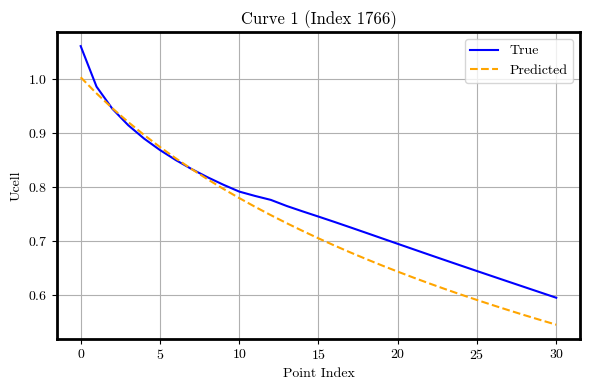

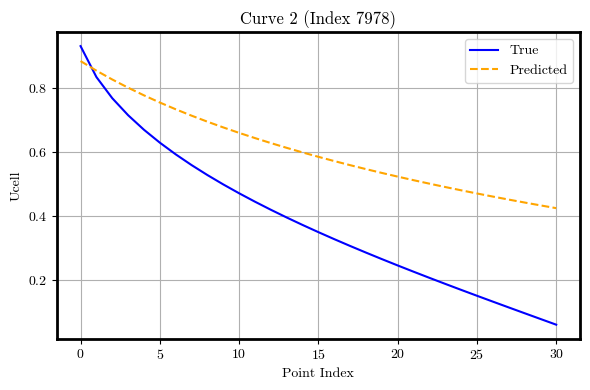

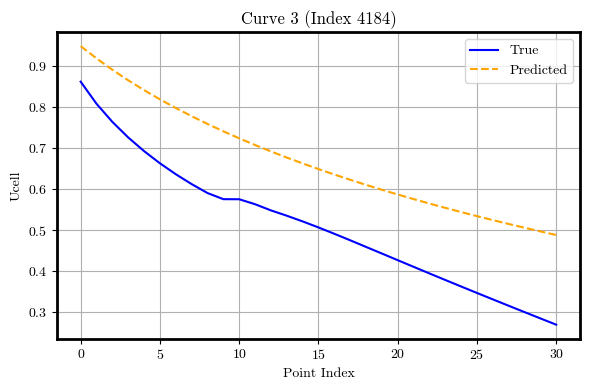

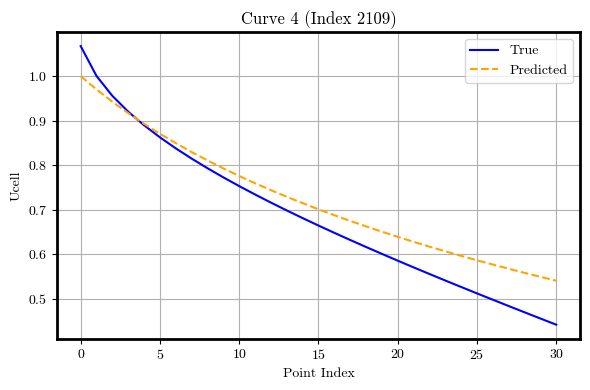

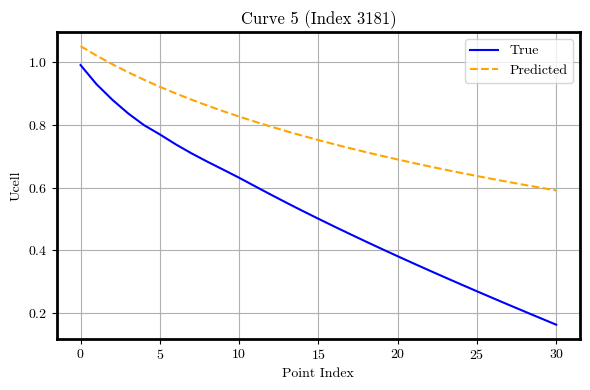

In [182]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predicted_vs_true_curves(results_df, equation_index, n_curves=5, seed=42):

    y = np.array(results_df['Ucell'].iloc[equation_index])
    y_pred = np.array(results_df['Ucell_pred'].iloc[equation_index])
    
    points_per_curve = 31
    total_points = len(y)
    total_curves = total_points // points_per_curve

    np.random.seed(seed)
    selected_indices = np.random.choice(total_curves, size=n_curves, replace=False)

    for i, curve_idx in enumerate(selected_indices):
        start = curve_idx * points_per_curve
        end = start + points_per_curve

        x = np.arange(points_per_curve)
        y_true_curve = y[start:end]
        y_pred_curve = y_pred[start:end]

        plt.figure(figsize=(6, 4))
        plt.plot(x, y_true_curve, label='True', linestyle='-', color='blue')
        plt.plot(x, y_pred_curve, label='Predicted', linestyle='--', color='orange')
        plt.title(f'Curve {i+1} (Index {curve_idx})')
        plt.xlabel('Point Index')
        plt.ylabel('Ucell')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_predicted_vs_true_curves(results_df=results, equation_index=12)


In [135]:
results.sort_values(by='r2', ascending=False, inplace=True)

In [136]:
for idx, row in results.iterrows():
    equation_str = row['equation']
    
    # Replace x0, x1, ... with parameter names in the string
    for i, name in enumerate(parameters):
        equation_str = equation_str.replace(f"x{i}", name)

    print(f"Equation: {equation_str}  R²: {row['r2']:.4f}, MSE: {row['mse']:.4f}")

Equation: ((5.566172 - log(Tfc)) + exp(ifc * -0.19668856)) + (((Pa_des * 1.5634667e-7) + 0.019375514) * (log(i0_c_ref) + kappa_c))  R²: 0.8540, MSE: 0.0042
Equation: (log(i0_c_ref * Pa_des) * ((kappa_c - -21.793362) / (tau + Tfc))) + (log(ifc + 1.1002212) * -0.35250014)  R²: 0.8496, MSE: 0.0043
Equation: (log(Pa_des * i0_c_ref) * ((kappa_c - -21.88134) / Tfc)) + (log(ifc + 1.1418785) * -0.3569289)  R²: 0.8473, MSE: 0.0043
Equation: (log(Pa_des * i0_c_ref) * ((kappa_c - -19.627752) / Tfc)) + ((ifc * Tfc) * -0.00042480757)  R²: 0.8329, MSE: 0.0048
Equation: (log(Pa_des * i0_c_ref) * ((kappa_c - -19.625483) / Tfc)) + (ifc * -0.1474275)  R²: 0.8280, MSE: 0.0049
Equation: (ifc * -0.1474275) + (log(Pa_des * i0_c_ref) * (20.864273 / Tfc))  R²: 0.7968, MSE: 0.0058
Equation: (ifc * -0.14658587) + (log(Pa_des * i0_c_ref) * 0.059901953)  R²: 0.7560, MSE: 0.0069
Equation: (i0_c_ref + 302.89352) / (Tfc + (ifc * 97.37452))  R²: 0.7386, MSE: 0.0074
Equation: inv(exp(ifc * 0.20674461) + inv(i0_c_ref))

In [137]:
from sympy import sympify, latex

def add_latex_column(results_df, parameters):
    latex_eqs = []

    for eq in results_df['equation']:
        # Replace x0, x1, ... with actual names
        for i, name in enumerate(parameters):
            eq = eq.replace(f"x{i}", name)

        try:
            expr = sympify(eq)
            latex_eqs.append(latex(expr))
        except Exception as e:
            latex_eqs.append(f"Invalid: {e}")

    results_df['latex'] = latex_eqs
    return results_df

results_df = add_latex_column(results, parameters)
print(results_df[['equation', 'latex']])


                                             equation  \
14  ((5.566172 - log(Tfc)) + exp(ifc * -0.19668856...   
13  (log(i0_c_ref * Pa_des) * ((kappa_c - -21.7933...   
12  (log(Pa_des * i0_c_ref) * ((kappa_c - -21.8813...   
11  (log(Pa_des * i0_c_ref) * ((kappa_c - -19.6277...   
10  (log(Pa_des * i0_c_ref) * ((kappa_c - -19.6254...   
9   (ifc * -0.1474275) + (log(Pa_des * i0_c_ref) *...   
8   (ifc * -0.14658587) + (log(Pa_des * i0_c_ref) ...   
7   (i0_c_ref + 302.89352) / (Tfc + (ifc * 97.37452))   
6          inv(exp(ifc * 0.20674461) + inv(i0_c_ref))   
5            exp((inv(i0_c_ref) + ifc) * -0.22105232)   
4                  inv((ifc * 0.2868409) + 1.0120518)   
3                           inv(log(ifc + 2.7495902))   
2                                exp(ifc * -0.229922)   
1                                     249.33754 / Tfc   
0                                          0.71649367   

                                                latex  
14  \left(1.5634667 \cdot 10^{-

In [138]:
from IPython.display import display, Math

for _, row in results_df.head(30).iterrows():
    eq_latex = row['latex']
    r2 = row['r2']
    mse = row['mse']
    
    display(Math(
        rf"\text{{Equation: }} {eq_latex} \\ \text{{R}}^2 = {r2:.4f}, \quad \text{{MSE}} = {mse:.4f}"
    ))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [139]:
import numpy as np

equation_str = "((kappa_c + log( )) * ((Pa_des * 1.5976357e-7) + 0.019371508)) + ((5.5642056 - log(Tfc)) + exp(ifc * -0.19848849))"
equation_str = equation_str.replace("log", "np.log").replace("exp", "np.exp")

class SymbolicModel:
    def __init__(self, equation: str):
        self.equation = (
            equation.replace("log", "np.log")
                    .replace("exp", "np.exp")
                    .replace("^", "**")
        )
        self.feature_names = None  # <- will set this later

    def predict(self, X):
        # Save feature names if it's a DataFrame
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            return X.apply(lambda row: eval(self.equation, {"np": np}, row.to_dict()), axis=1)
        
        elif isinstance(X, np.ndarray):
            if self.feature_names is None:
                raise ValueError("Feature names must be set before calling predict with numpy array.")
            X_df = pd.DataFrame(X, columns=self.feature_names)
            return self.predict(X_df)

        elif isinstance(X, dict):
            return eval(self.equation, {"np": np}, X)
        
        else:
            raise ValueError("Input must be a dict, DataFrame, or numpy array.")




In [140]:
model = SymbolicModel("((kappa_c + log(i0_c_ref)) * ((Pa_des * 1.5976357e-7) + 0.019371508)) + ((5.5642056 - log(Tfc)) + exp(ifc * -0.19848849))")


prediction = model.predict(test_df[parameters])
print("Prediction:", prediction)


Prediction: 4        1.010201
4        0.990552
4        0.971288
4        0.952403
4        0.933889
           ...   
57340    0.598404
57340    0.586676
57340    0.575178
57340    0.563906
57340    0.552856
Length: 335916, dtype: float64


In [141]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(test_df['Ucell'], prediction)
mse = mean_squared_error(test_df['Ucell'], prediction)

print(f"R² score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


R² score: 0.8538
Mean Squared Error: 0.0042


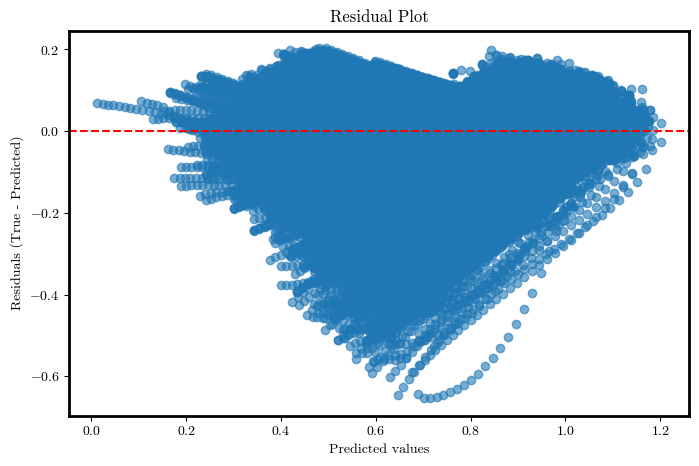

In [142]:
import matplotlib.pyplot as plt

residuals = test_df['Ucell'] - prediction

plt.figure(figsize=(8,5))
plt.scatter(prediction, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals (True - Predicted)')
plt.title('Residual Plot')
plt.show()


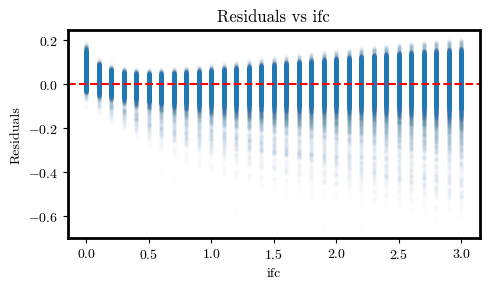

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3))
sns.scatterplot(
    x=test_df['ifc'], 
    y=residuals, 
    alpha=0.01,        # Makes points semi-transparent
    s=10              # Smaller marker size
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs ifc")
plt.xlabel("ifc")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()


In [144]:
import numpy as np
import pandas as pd

# Define bin edges
bins = np.arange(-0.8, 0.4 + 0.2, 0.2)  # [-0.8, -0.6), ..., [0.2, 0.4)

# Bin residuals (right=False makes bins like [a, b))
binned = pd.cut(residuals, bins=bins, right=False)

# Count values per bin
counts = binned.value_counts().sort_index()

# Compute percentages
percentages = counts / counts.sum() * 100

# Combine into one DataFrame
summary = pd.DataFrame({
    "Count": counts,
    "Percentage": percentages.round(2)  # optional: round for readability
})

print(summary)


                    Count  Percentage
[-0.8, -0.6)           13        0.00
[-0.6, -0.4)          588        0.18
[-0.4, -0.2)         3846        1.14
[-0.2, -2.22e-16)  149427       44.48
[-2.22e-16, 0.2)   182039       54.19
[0.2, 0.4)              3        0.00


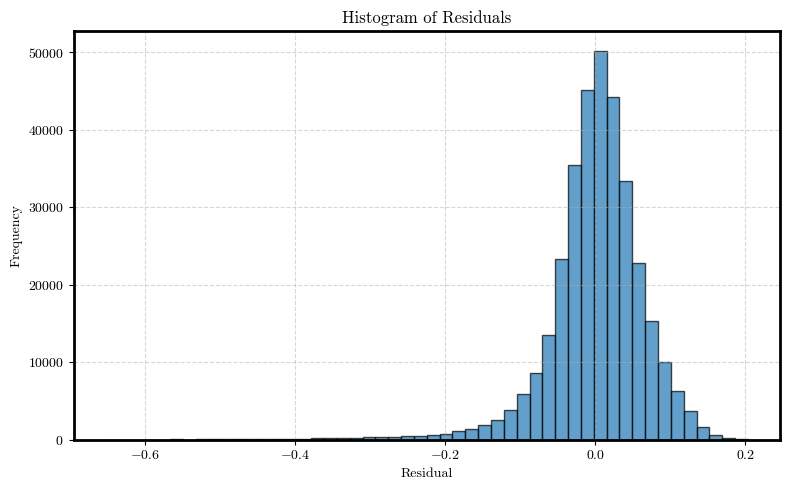

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\dejvi\AppData\Local\Temp\ipykernel_4420\1215213383.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = residuals_df.groupby('bin')


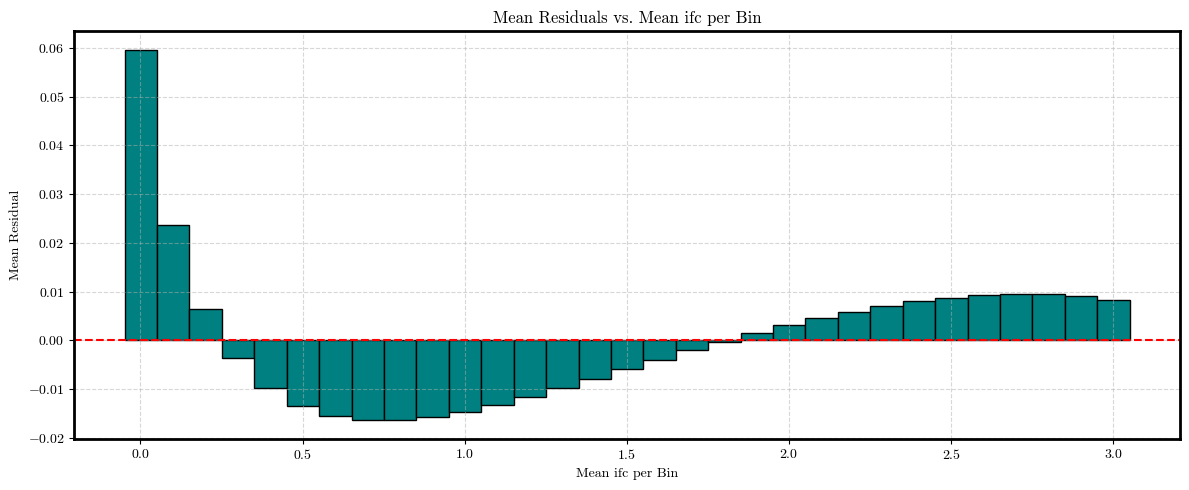

In [146]:
import pandas as pd
import matplotlib.pyplot as plt

# Bin the data
bins = pd.cut(test_df['ifc'], bins=31)
residuals_df = pd.DataFrame({'ifc': test_df['ifc'], 'residuals': residuals, 'bin': bins})

# Calculate mean residual and mean ifc per bin
grouped = residuals_df.groupby('bin')
mean_residuals = grouped['residuals'].mean()
mean_ifc = grouped['ifc'].mean()

# Plot
plt.figure(figsize=(12, 5))
plt.bar(mean_ifc, mean_residuals, width=(mean_ifc.diff().mean()), color='teal', edgecolor='black')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Mean ifc per Bin")
plt.ylabel("Mean Residual")
plt.title("Mean Residuals vs. Mean ifc per Bin")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\dejvi\AppData\Local\Temp\ipykernel_4420\1704378664.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = residuals_df.groupby('bin')


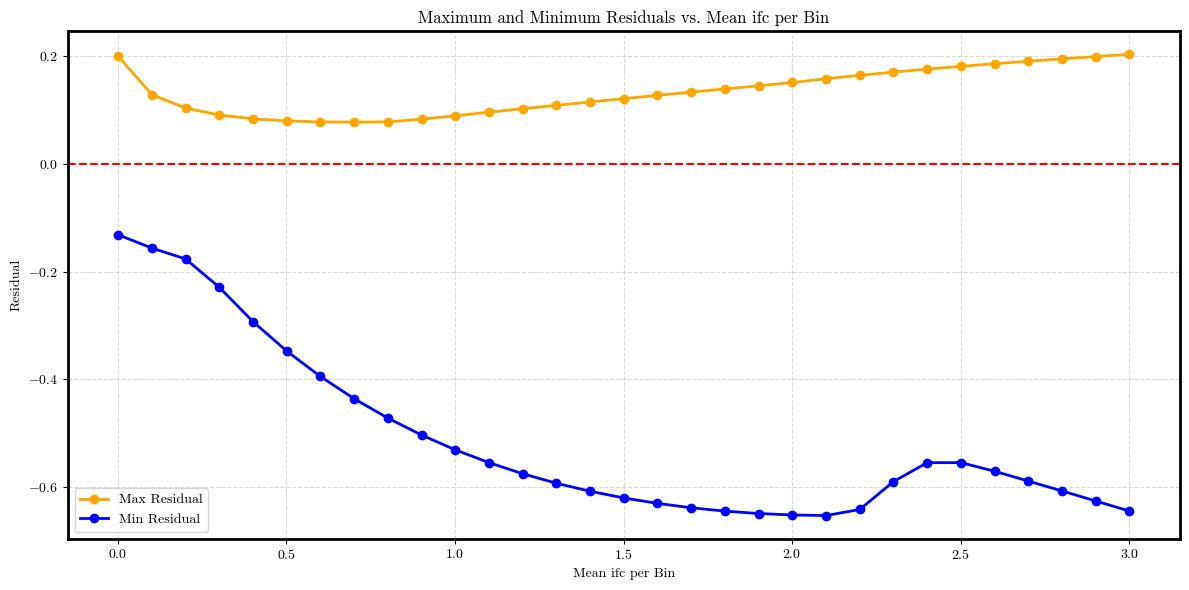

In [147]:
import pandas as pd
import matplotlib.pyplot as plt

# Bin the data
bins = pd.cut(test_df['ifc'], bins=31)
residuals_df = pd.DataFrame({'ifc': test_df['ifc'], 'residuals': residuals, 'bin': bins})

# Calculate max, min residuals and mean ifc per bin
grouped = residuals_df.groupby('bin')
max_residuals = grouped['residuals'].max()
min_residuals = grouped['residuals'].min()
mean_ifc = grouped['ifc'].mean()

# Plot max and min residuals
plt.figure(figsize=(12, 6))
plt.plot(mean_ifc, max_residuals, color='orange', marker='o', linestyle='-', linewidth=2, label='Max Residual')
plt.plot(mean_ifc, min_residuals, color='blue', marker='o', linestyle='-', linewidth=2, label='Min Residual')

plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Mean ifc per Bin")
plt.ylabel("Residual")
plt.title("Maximum and Minimum Residuals vs. Mean ifc per Bin")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import shap
explainer = shap.KernelExplainer(model.predict, test_df[parameters].sample(100, random_state=1))
shap_values = explainer.shap_values(test_df[parameters].sample(1000, random_state=1), nsamples=100)



100%|██████████| 1000/1000 [05:48<00:00,  2.87it/s]


C:\Users\dejvi\AppData\Local\Temp\ipykernel_26252\2418254866.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, exploaded_df[parameters].sample(1000, random_state=1))


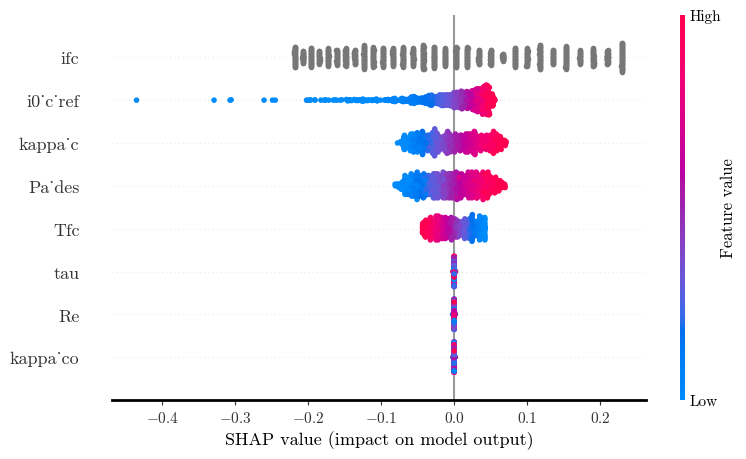

In [ ]:
shap.summary_plot(shap_values, test_df[parameters].sample(1000, random_state=1))


C:\Users\dejvi\AppData\Local\Temp\ipykernel_26252\1739467285.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, exploaded_df[parameters].sample(1000, random_state=1), plot_type="bar")


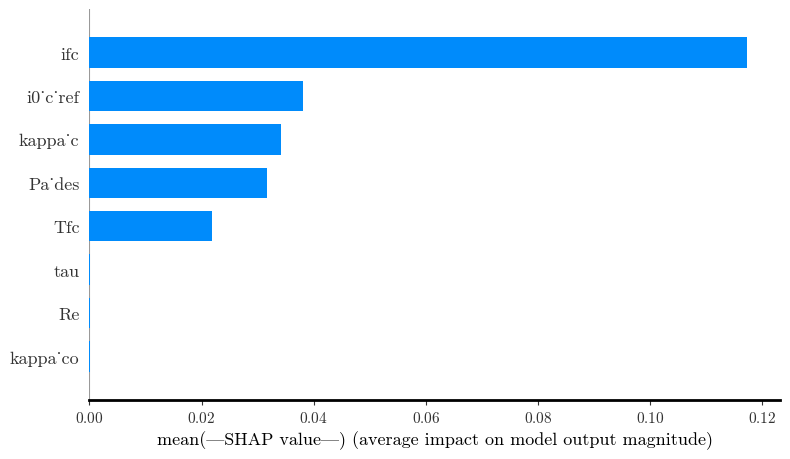

In [ ]:
shap.summary_plot(shap_values, test_df[parameters].sample(1000, random_state=1), plot_type="bar")


In [184]:
df_all_equations_informed = load_all_pysr_equations(output_csv=None)
df_all_equations_informed = df_all_equations_informed[df_all_equations_informed['model_folder'] == '20250728_153643_P6n6Dn']


In [185]:
import re

def replace_hash_variables(expr: str, variable_names: list[str]) -> str:
    """
    Replace #n placeholders with corresponding variable names from variable_names.
    Uses word boundary to avoid partial replacements (e.g., not replacing #4 inside 'square').
    """
    def replacer(match):
        idx = int(match.group(1)) - 1  # #1 -> variable_names[0]
        if 0 <= idx < len(variable_names):
            return variable_names[idx]
        else:
            # If index out of range, return original text unchanged
            return match.group(0)
    return re.sub(r"#(\d+)\b", replacer, expr)


def expand_template_expression(expr_string: str, combine_template: str, variable_names: list[str]) -> str:
    """
    1) Replace all #n with variable names in the raw expression.
    2) Parse assignments like a = ..., b = ...
    3) Replace a,b,c,d,e in the template with the corresponding expanded expressions.
    """
    # Step 1: Replace #n in the whole expr_string (the assignments section)
    expr_string = replace_hash_variables(expr_string, variable_names)

    # Step 2: Parse assignments like a = ..., b = ..., c = ..., etc.
    assignments = dict(re.findall(r'([a-e])\s*=\s*([^;]+?)(?:;|\s*$)', expr_string))

    full_equation = combine_template
    for name, expression in assignments.items():
        # Use word boundary \b to avoid partial matches (like replacing 'a' inside 'square')
        full_equation = re.sub(rf"\b{name}\b", f"({expression})", full_equation)

    return full_equation

combine_template = (
    "a "
    "- b*log(ifc) "
    "- c*ifc "
    "- d*log(1- ifc / e)"
)

df_all_equations_informed = df_all_equations_informed
df_all_equations_informed.rename(columns={"Equation": "RawEquation"}, inplace=True)


df_all_equations_informed["Equation"] = df_all_equations_informed["RawEquation"].apply(
    lambda expr: expand_template_expression(expr, combine_template, parameters)
)

df_all_equations_informed



,Complexity,Loss,RawEquation,model_folder,Equation
528,5,0.010508,a = 1.0132672; b = #7; c = 0.06079287; d = 0.1...,20250728_153643_P6n6Dn,(1.0132672) - (Re)*log(ifc) - (0.06079287)*ifc...
529,6,0.009243,a = 0.9493543; b = #7; c = 0.14057112; d = 0.1...,20250728_153643_P6n6Dn,(0.9493543) - (Re)*log(ifc) - (0.14057112)*ifc...
530,7,0.008277,a = 0.8150413; b = 0.03607741; c = 0.12077918;...,20250728_153643_P6n6Dn,(0.8150413) - (0.03607741)*log(ifc) - (0.12077...
531,9,0.008114,a = 0.9807587; b = 0.0055368203; c = 1.5332146...,20250728_153643_P6n6Dn,(0.9807587) - (0.0055368203)*log(ifc) - (1.533...
532,10,0.008005,a = 0.9045313; b = 0.01795832; c = 1.7414298 /...,20250728_153643_P6n6Dn,(0.9045313) - (0.01795832)*log(ifc) - (1.74142...
533,11,0.007472,a = 4.9039993; b = -0.48875228; c = 3.0267947 ...,20250728_153643_P6n6Dn,(4.9039993) - (-0.48875228)*log(ifc) - (3.0267...
534,13,0.007435,a = 1.0554602; b = -0.00725308; c = 1.8428147 ...,20250728_153643_P6n6Dn,(1.0554602) - (-0.00725308)*log(ifc) - (1.8428...
535,14,0.007050,a = inv(#1 * 0.0028587314); b = 0.0014232226; ...,20250728_153643_P6n6Dn,(inv(Tfc * 0.0028587314)) - (0.0014232226)*log...
536,16,0.007046,a = inv(#1 * 0.0028587314); b = 0.03074044 / #...,20250728_153643_P6n6Dn,(inv(Tfc * 0.0028587314)) - (0.03074044 / kapp...
537,18,0.006909,a = inv((#1 - #4) * 0.0028587314); b = 0.03074...,20250728_153643_P6n6Dn,(inv((Tfc - kappa_c) * 0.0028587314)) - (0.030...


In [186]:
results_informed = evaluate_equations_with_parameters(
    df_all_equations_informed,
    df,
    test_df['Ucell'],
    parameters
)

In [187]:
results_informed.sort_values(by='r2', ascending=False, inplace=True)

In [188]:
results_informed_df = add_latex_column(results_informed, parameters)
print(results_informed_df[['equation', 'latex']])

                                             equation  \
14  (inv(Tfc * (Re + 0.0029262616))) - (-1.8793446...   
13  (inv(Tfc * 0.0029262616)) - (-1.8793446 / ((Pa...   
12  (inv(Tfc * 0.0029262616)) - (square(kappa_c) /...   
11  (inv(Tfc * 0.0029262616)) - (kappa_c / Tfc)*lo...   
10  (inv(Tfc * 0.0029262616)) - (0.006386592)*log(...   
9   (inv((Tfc - kappa_c) * 0.0028587314)) - (0.030...   
8   (inv(Tfc * 0.0028587314)) - (0.03074044 / kapp...   
7   (inv(Tfc * 0.0028587314)) - (0.0014232226)*log...   
6   (1.0554602) - (-0.00725308)*log(ifc) - (1.8428...   
5   (4.9039993) - (-0.48875228)*log(ifc) - (3.0267...   
4   (0.9045313) - (0.01795832)*log(ifc) - (1.74142...   
3   (0.9807587) - (0.0055368203)*log(ifc) - (1.533...   
2   (0.8150413) - (0.03607741)*log(ifc) - (0.12077...   
1   (0.9493543) - (Re)*log(ifc) - (0.14057112)*ifc...   
0   (1.0132672) - (Re)*log(ifc) - (0.06079287)*ifc...   

                                                latex  
14  - \frac{0.28410208 ifc \tau

In [189]:
from IPython.display import display, Math

for _, row in results_informed_df.head(30).iterrows():
    eq_latex = row['latex']
    r2 = row['r2']
    mse = row['mse'] 
    
    display(Math(
        rf"\text{{Equation: }} {eq_latex} \\ \text{{R}}^2 = {r2:.4f}, \quad \text{{MSE}} = {mse:.4f}"
    ))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

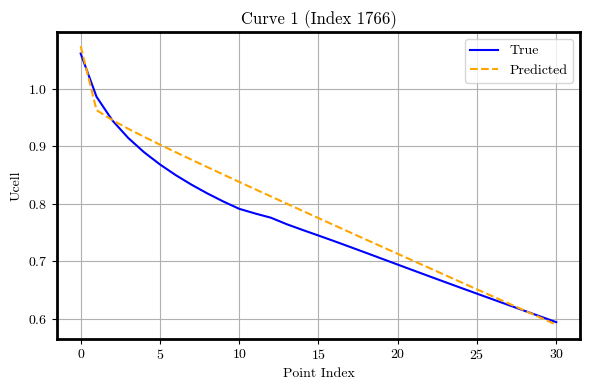

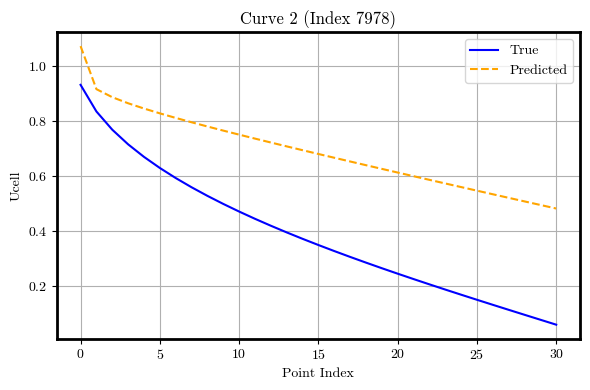

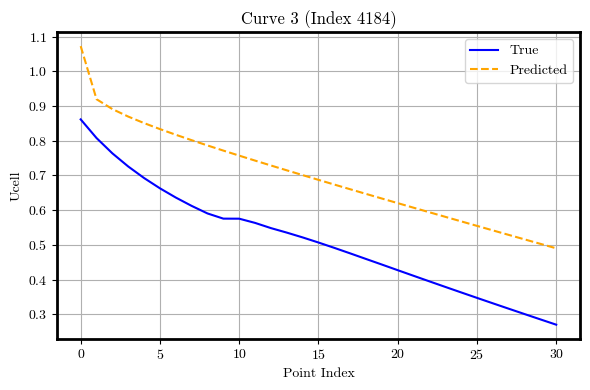

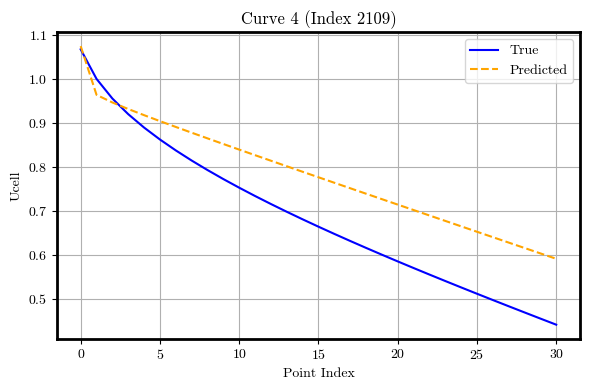

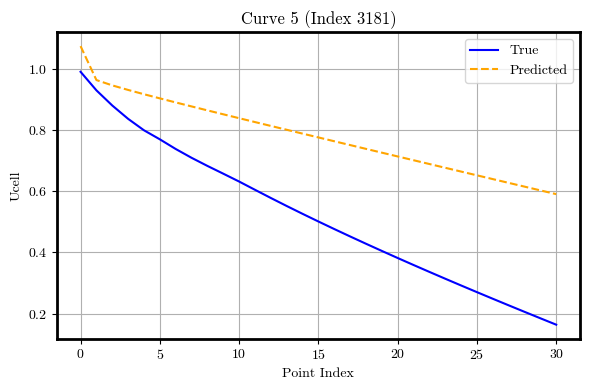

In [190]:
plot_predicted_vs_true_curves(results_df=results_informed, equation_index=12)